Filename : notebook_02.ipynb <br>
Description : Workshop 1 - Analyze and Visualize Customer Data

---

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
pd.options.display.float_format = "{:.2f}".format

<small>1. Load the dataset from "ifood.xlsx" and check the number of rows and columns in the DataFrame.

In [68]:
df = pd.read_excel("ifood.xlsx")

---

<small>2. Calculate the mean, median, and mode of the "Income" column. 

In [69]:
print("Income Mean = ", df['Income'].mean())
print("Income Median = ", df['Income'].median())
print("Income Mode = ", df['Income'].mode()[0])


Income Mean =  51622.0947845805
Income Median =  51287.0
Income Mode =  7500


---

<small>3.Create a histogram of the "Age" column with gridlines and clear labels.


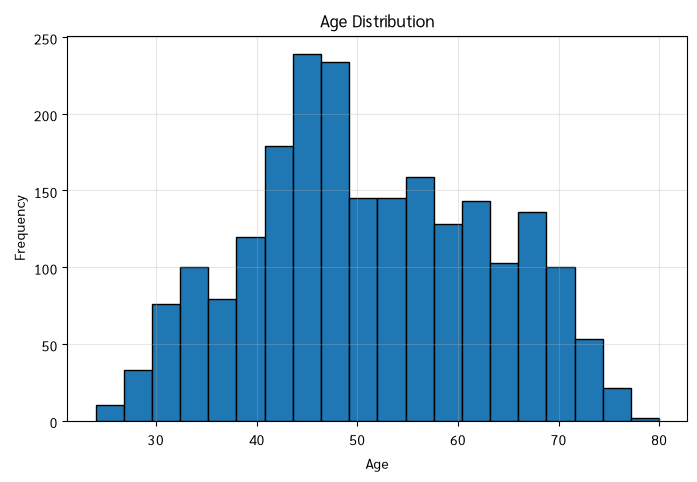

In [70]:
plt.hist(df['Age'], bins=20, edgecolor='black')

plt.grid(True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

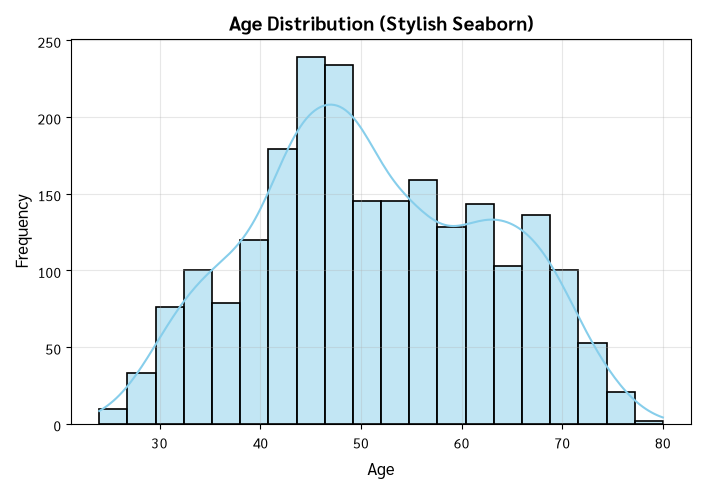

In [71]:
sns.histplot(df["Age"], bins=20, kde=True, 
             color="skyblue", edgecolor="black", linewidth=1.2)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Age Distribution (Stylish Seaborn)", fontsize=14, weight="bold")
plt.show()

---

<small>4. Compute the range and interquartile range (IQR) of the "MntWines" column. 


In [72]:
rng = df['MntWines'].max() - df['MntWines'].min()
iqr = df['MntWines'].quantile(0.75) - df['MntWines'].quantile(0.25)
print("Range:", rng)
print("IQR  :", iqr)

Range: 1493
IQR  : 483.0


---

<small>5. Use "pd.cut" to divide "Income" into 4 ranges and count the number of customers in each group.

In [73]:
df['IncomeGroup'] = pd.cut(df['Income'], bins=4)
print(df['IncomeGroup'].value_counts())

IncomeGroup
(29731.0, 57732.0]     941
(57732.0, 85733.0]     822
(1617.996, 29731.0]    363
(85733.0, 113734.0]     79
Name: count, dtype: int64


---

<small>6. Compute the average spending on meat products "MntMeatProducts" grouped by education level "Education".


In [74]:
df.groupby('Education')['MntMeatProducts'].mean().round(2)

Education
2nCycle      136.38
Basic         11.44
Graduation   179.31
Master       163.34
PhD          163.57
Name: MntMeatProducts, dtype: float64

---

<small>7. Use GroupBy to calculate the average "Income" by marital status "Marital".


In [75]:
df.groupby('Marital')['Income'].mean().round(2)

Marital
Divorced   52465.12
Married    51350.51
Single     51009.62
Together   51553.20
Widow      56481.55
Name: Income, dtype: float64

---

<small>8. Calculate the proportion of customers who responded to the latest campaign "Response = 1"


In [76]:
prop = (df['Response'] == 1).mean().round(2)
print("Response proportion:", prop)

Response proportion: 0.15


---

<small>9. Create a bar chart showing the number of customers in each marital status category "Marital" using Matplotlib. 


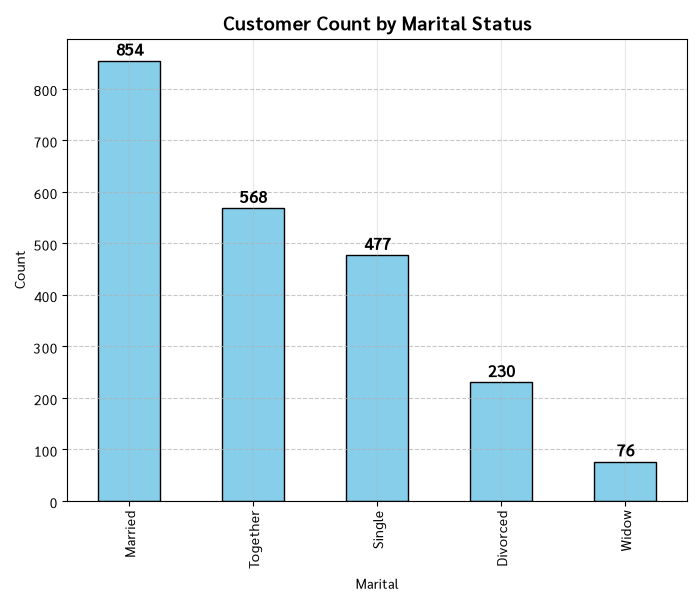

In [77]:
counts = df['Marital'].value_counts()

ax = counts.plot(kind='bar', figsize=(8,6), color="skyblue", edgecolor="black")

for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=12, weight="bold")

plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.title("Customer Count by Marital Status", fontsize=14, weight="bold")
plt.ylabel("Count")
plt.show()

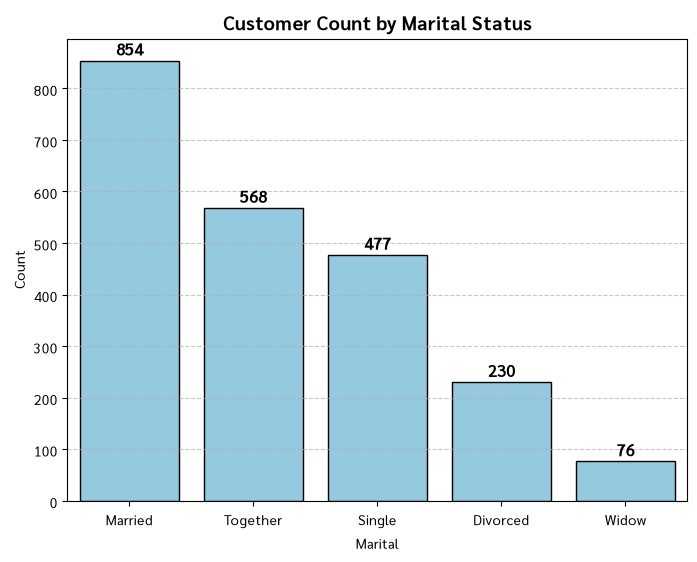

In [78]:
counts = df['Marital'].value_counts().reset_index()
counts.columns = ["Marital", "Count"]

plt.figure(figsize=(8,6))
ax = sns.barplot(data=counts, x="Marital", y="Count", color="skyblue", edgecolor="black")

for i, v in enumerate(counts["Count"]):
    ax.text(i, v + 10, str(v), ha='center', fontsize=12, weight="bold")

plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.title("Customer Count by Marital Status", fontsize=14, weight="bold")
plt.ylabel("Count")
plt.show()

---

<small>10. Calculate the Pearson correlation between "Income" and "MntWines". 

In [79]:
df['Income'].corr(df['MntWines']).round(2)

np.float64(0.73)

---

<small>11. Create a boxplot of "Income" grouped by education level "Education".


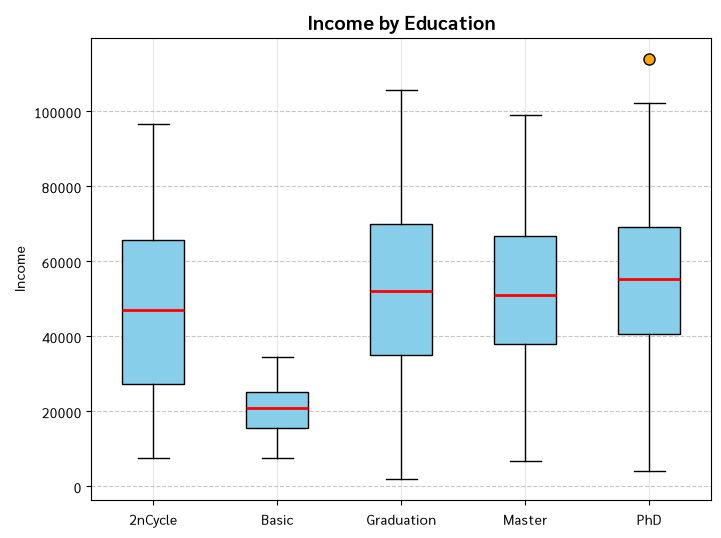

In [80]:
groups = df.groupby("Education")["Income"]

plt.figure(figsize=(8,6))
plt.boxplot([groups.get_group(g) for g in groups.groups],
            tick_labels=groups.groups.keys(),  
            patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="black"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(markerfacecolor="orange", marker="o", markersize=8))

plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.title("Income by Education", fontsize=14, weight="bold")
plt.ylabel("Income")
plt.show()

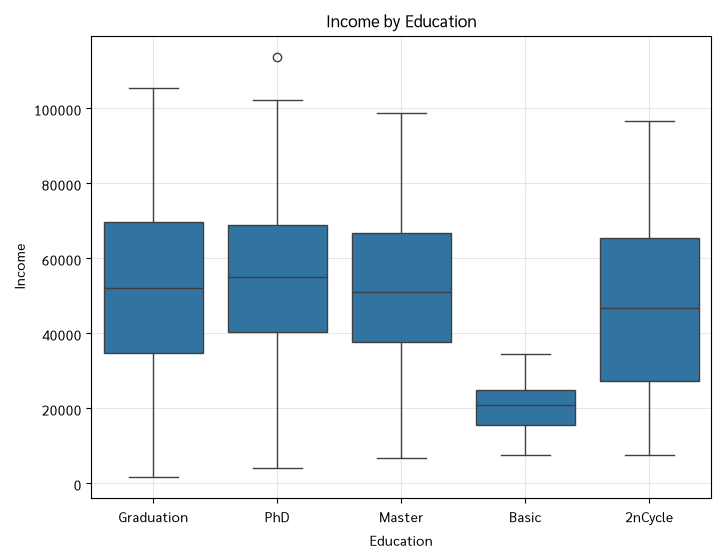

In [81]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Education', y='Income', data=df)
plt.grid(True)
plt.title("Income by Education")
plt.show()

---

<small>12. Calculate the skewness and kurtosis of the "MntGoldProds" column. 


In [82]:
print("Skewness:", df['MntGoldProds'].skew())
print("Kurtosis:", df['MntGoldProds'].kurt())

Skewness: 1.8344675453615618
Kurtosis: 3.1437591880481612


---

<small>13. Create a pairplot of "MntWines", "MntMeatProducts", and "MntSweetProducts" to explore relationships.


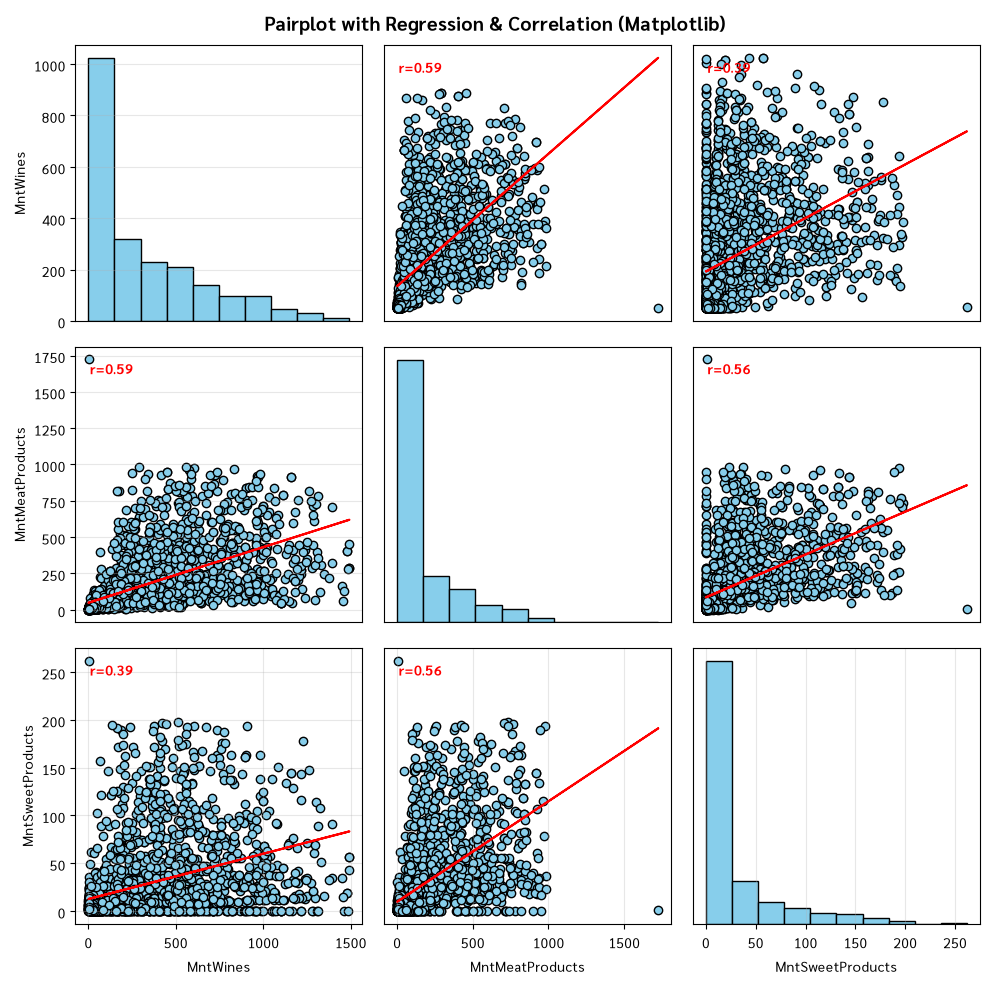

In [83]:
features = ["MntWines","MntMeatProducts","MntSweetProducts"]
n = len(features)

fig, axes = plt.subplots(n, n, figsize=(10,10))

for i, f1 in enumerate(features):
    for j, f2 in enumerate(features):
        ax = axes[i,j]
        if i == j:
            # Histogram บน diagonal
            ax.hist(df[f1], bins=10, color="skyblue", edgecolor="black")
        else:
            # Scatter plot
            ax.scatter(df[f2], df[f1], color="skyblue", edgecolor="black")

            # Regression line
            m, b = np.polyfit(df[f2], df[f1], 1)
            ax.plot(df[f2], m*df[f2] + b, color="red")

            # Correlation r
            r = np.corrcoef(df[f2], df[f1])[0,1]
            ax.text(0.05, 0.9, f"r={r:.2f}", transform=ax.transAxes,
                    fontsize=10, weight="bold", color="red")

        # Label axes
        if i == n-1:
            ax.set_xlabel(f2)
        else:
            ax.set_xticks([])
        if j == 0:
            ax.set_ylabel(f1)
        else:
            ax.set_yticks([])

plt.suptitle("Pairplot with Regression & Correlation (Matplotlib)", fontsize=14, weight="bold")
plt.tight_layout()

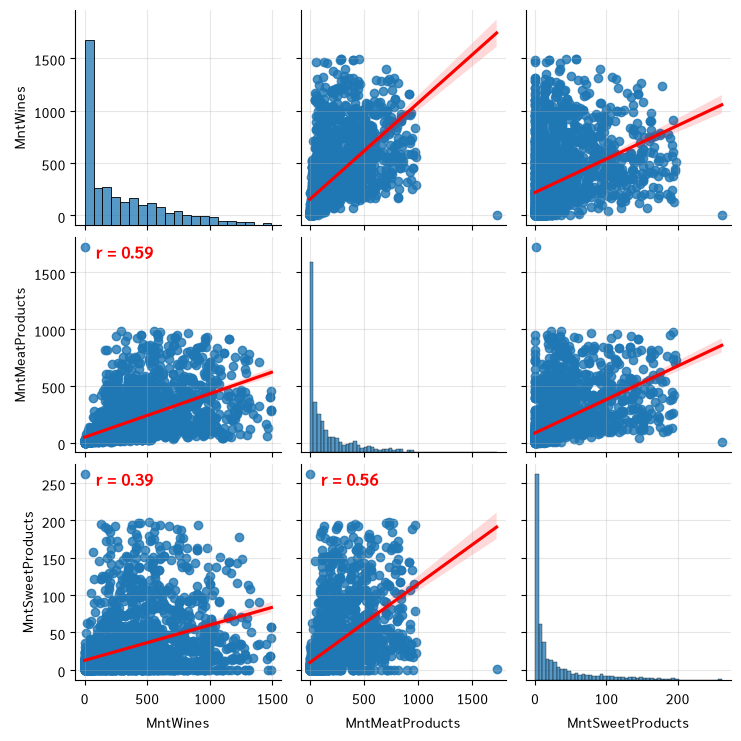

In [84]:
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0,1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}", 
                xy=(0.1, 0.9), xycoords=ax.transAxes,
                fontsize=12, weight="bold", color="red")

# สร้าง Pairplot พร้อม regression line และค่า r
g = sns.pairplot(df[["MntWines","MntMeatProducts","MntSweetProducts"]],
                 kind="reg", plot_kws={"line_kws":{"color":"red"}})

# ใส่ค่า r ในกราฟด้านล่าง
g.map_lower(corrfunc)

plt.show()

---

<small>14. Filter customers with children "Kidhome" + "Teenhome" > 0 and compute their average "Income"


In [85]:
subset = df[(df['Kidhome'] + df['Teenhome']) > 0]
print("Average Income (with children):", subset['Income'].mean().round(2))

Average Income (with children): 46257.09


---

<small>15. Find the top 10 customers with the highest spending on wine "MntWines". 


In [86]:
df.nlargest(10, 'MntWines')[['No','MntWines']]

,No,MntWines
1723,1724,1493
542,543,1492
804,805,1492
2066,2067,1486
526,527,1478
897,898,1478
1935,1936,1462
1616,1617,1459
1463,1464,1449
480,481,1396


---

<small>16. Use "pd.qcut" to divide "Income" into 4 quantiles and count customers in each group. 


In [87]:
df['IncomeQuantile'] = pd.qcut(df['Income'], 4)
print(df['IncomeQuantile'].value_counts())

IncomeQuantile
(1729.999, 35196.0]    553
(51287.0, 68281.0]     551
(68281.0, 113734.0]    551
(35196.0, 51287.0]     550
Name: count, dtype: int64


---

<small>17. Create a stacked bar chart showing the number of customers by marital status "Marital" and education "Education". 

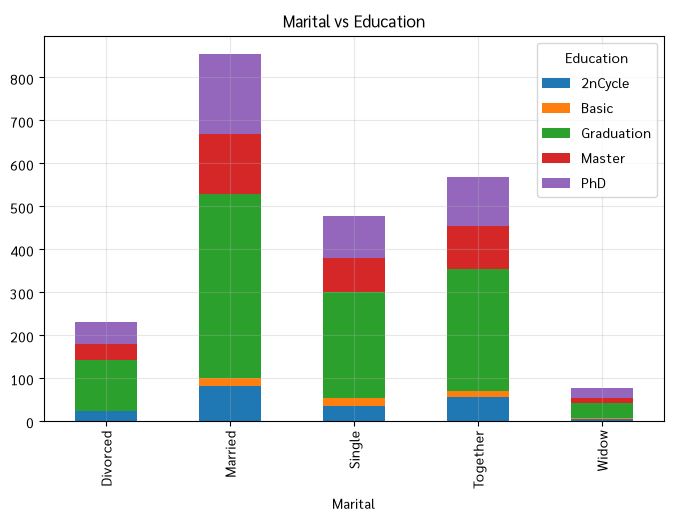

In [88]:
pd.crosstab(df['Marital'], df['Education']).plot(kind='bar', stacked=True)
plt.grid(True)
plt.title("Marital vs Education")
plt.show()

---

<small>18. Calculate the average "NumWebPurchases" and "NumWebVisitsMonth" grouped by marital status "Marital". 

In [89]:
df.groupby('Marital')[['NumWebPurchases','NumWebVisitsMonth']].mean()

,NumWebPurchases,NumWebVisitsMonth
Marital,,
Divorced,4.34,5.51
Married,4.10,5.37
Single,3.88,5.29
Together,4.12,5.31
Widow,4.62,4.93


---

<small>19. Create a new column summing "AcceptedCmp1–5" and identify customers who accepted at least 2 campaigns.


In [90]:
df['TotalAccepted'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1)
df[df['TotalAccepted'] >= 2][['No','TotalAccepted']]

,No,TotalAccepted
14,15,2
49,50,2
55,56,2
62,63,2
81,82,2
...,...,...
2138,2139,3
2141,2142,2
2142,2143,2
2160,2161,2


---

<small>20. Create a heatmap of the correlation matrix for product spending variables "MntWines", "MntMeatProducts", "MntSweetProducts", "MntGoldProds". 


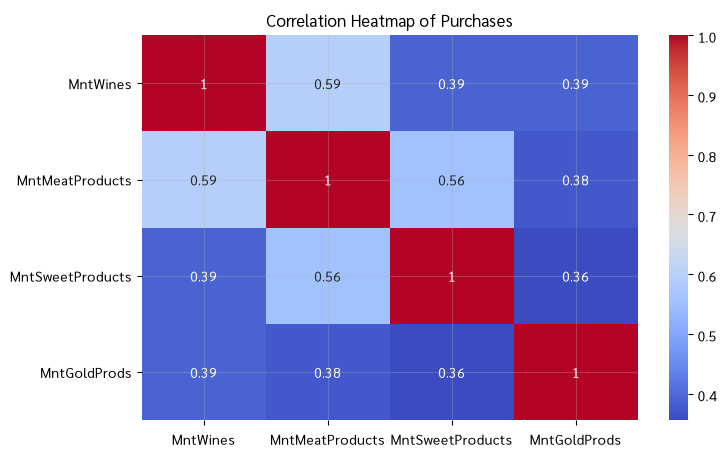

In [91]:
corr = df[['MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Purchases")
plt.show()

---

<small>21. Analyze whether higher "Income" is associated with higher spending on wine "MntWines". <br> What insight can be drawn about premium product targeting? 


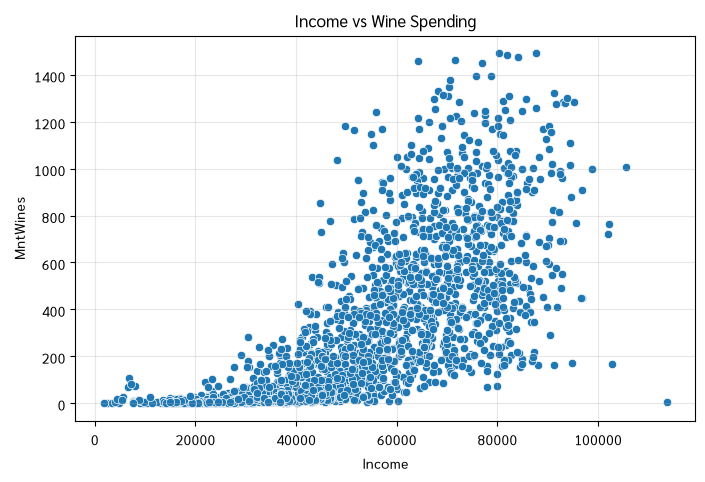

          Income  MntWines
Income      1.00      0.73
MntWines    0.73      1.00


In [92]:
sns.scatterplot(x='Income', y='MntWines', data=df)
plt.title("Income vs Wine Spending")
plt.grid(True)
plt.show()
print(df[['Income','MntWines']].corr())


---

<small>22. Compare average spending on meat "MntMeatProducts" across different "Education" levels. <br> What does this suggest about dietary preferences by education?


Education
2nCycle      136.38
Basic         11.44
Graduation   179.31
Master       163.34
PhD          163.57
Name: MntMeatProducts, dtype: float64


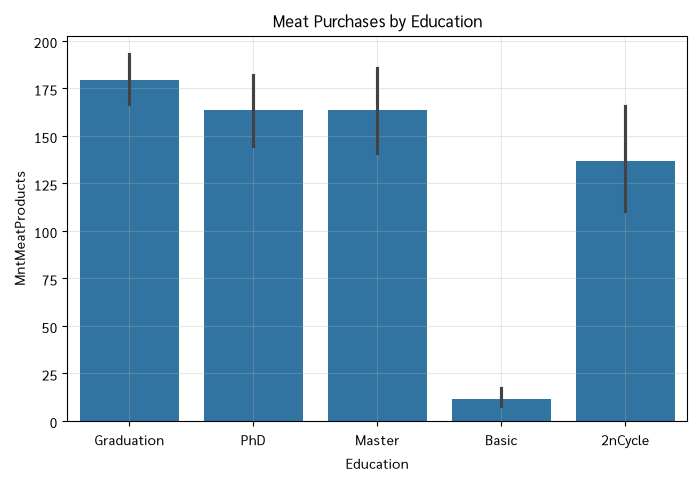

In [93]:
print(df.groupby('Education')['MntMeatProducts'].mean())
sns.barplot(x='Education', y='MntMeatProducts', data=df, estimator='mean')
plt.title("Meat Purchases by Education")
plt.grid(True)
plt.show()

---

<small>23. Examine differences in "NumWebPurchases" and "NumWebVisitsMonth" across "Marital" categories. <br> What insight can be drawn about digital engagement by family status?


          NumWebPurchases  NumWebVisitsMonth
Marital                                     
Divorced             4.34               5.51
Married              4.10               5.37
Single               3.88               5.29
Together             4.12               5.31
Widow                4.62               4.93


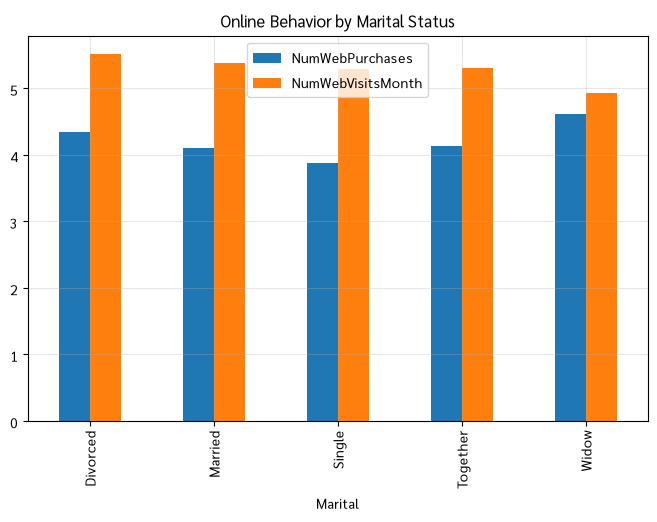

In [94]:
print(df.groupby('Marital')[['NumWebPurchases','NumWebVisitsMonth']].mean())
df.groupby('Marital')[['NumWebPurchases','NumWebVisitsMonth']].mean().plot(kind='bar')
plt.title("Online Behavior by Marital Status")
plt.grid(True)
plt.show()

---

<small>24. Investigate whether age "Age" influences the likelihood of responding to campaigns "Response". <br> Which age group is most receptive?


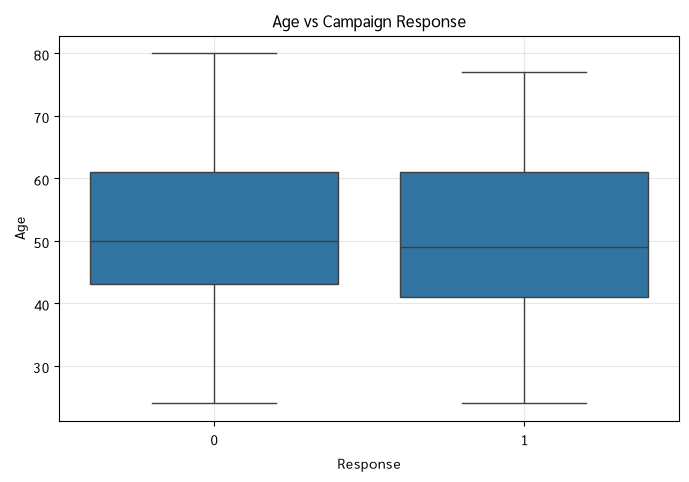

Response
0   51.20
1   50.50
Name: Age, dtype: float64


In [95]:
sns.boxplot(x='Response', y='Age', data=df)
plt.title("Age vs Campaign Response")
plt.grid(True)
plt.show()

print(df.groupby('Response')['Age'].mean())


---

<small>25. Compare average spending on sweets "MntSweetProducts" between households with children "Kidhome" + "Teenhome" > 0 and those without. <br> What does this reveal about family consumption patterns?


HasChildren
False   53.49
True    16.63
Name: MntSweetProducts, dtype: float64


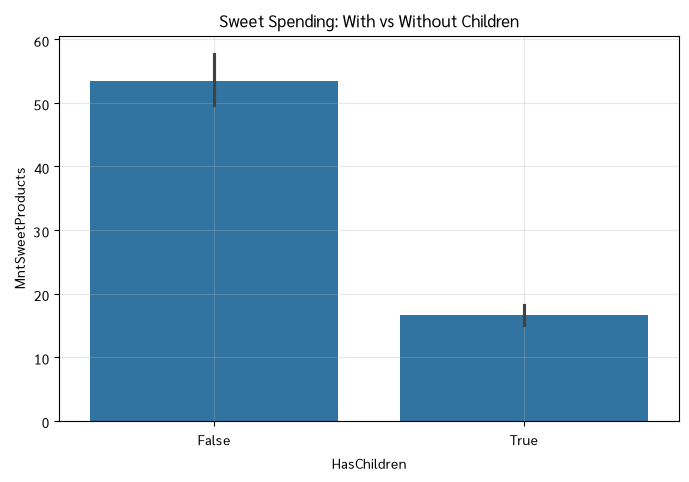

In [96]:
df['HasChildren'] = (df['Kidhome'] + df['Teenhome']) > 0
print(df.groupby('HasChildren')['MntSweetProducts'].mean())
sns.barplot(x='HasChildren', y='MntSweetProducts', data=df, estimator='mean')
plt.title("Sweet Spending: With vs Without Children")
plt.grid(True)
plt.show()

---

<small>26. Identify customers with the highest combined spending "MntWines" + "MntMeatProducts" + "MntGoldProds". <br>
What characteristics (age, marital, education) do they share? 


In [97]:
df['TotalSpending'] = df[['MntWines','MntMeatProducts','MntGoldProds']].sum(axis=1)
top_customers = df.nlargest(10,'TotalSpending')[['No','Age','Marital','Education','TotalSpending']]
print(top_customers)

        No  Age   Marital   Education  TotalSpending
967    968   51   Married  Graduation           2284
1032  1033   71   Married         PhD           2273
1159  1160   29    Single      Master           2167
1547  1548   29    Single      Master           2167
1467  1468   32  Together  Graduation           2107
626    627   73  Together      Master           2105
1433  1434   50    Single  Graduation           2078
923    924   67  Together  Graduation           2073
1280  1281   67  Together  Graduation           2073
1966  1967   73    Single      Master           2070


---

<small>27. Analyze customers who accepted multiple campaigns "AcceptedCmp1–5". <br>
What demographic or behavioral traits distinguish them?  


In [98]:
df['TotalAccepted'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1)
multi_accept = df[df['TotalAccepted'] >= 3]
print(multi_accept[['No','Age','Marital','Education','TotalAccepted']])

        No  Age   Marital   Education  TotalAccepted
115    116   37    Single  Graduation              3
190    191   43  Together         PhD              3
232    233   48   Married  Graduation              3
238    239   46  Divorced  Graduation              4
320    321   52  Divorced  Graduation              3
400    401   26  Together  Graduation              4
409    410   34   Married  Graduation              3
413    414   59    Single         PhD              4
542    543   61  Together  Graduation              4
558    559   43   Married         PhD              3
569    570   65     Widow  Graduation              3
683    684   32    Single      Master              3
714    715   47  Divorced  Graduation              3
715    716   71   Married  Graduation              3
733    734   51   Married  Graduation              3
771    772   63   Married         PhD              3
784    785   62   Married  Graduation              3
804    805   61  Together  Graduation         

---

<small>28. Explore the relationship between "Recency" (days since last purchase) and total spending. <br>
Do recent buyers tend to spend more? 


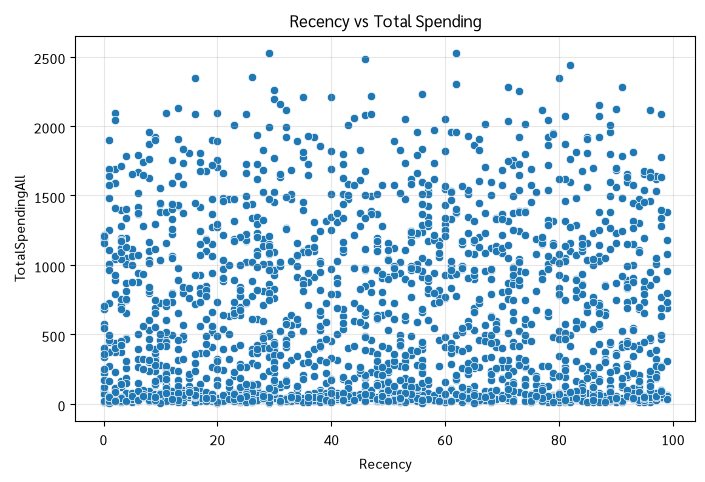

                  Recency  TotalSpendingAll
Recency              1.00              0.02
TotalSpendingAll     0.02              1.00


In [99]:
df['TotalSpendingAll'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
sns.scatterplot(x='Recency', y='TotalSpendingAll', data=df)
plt.title("Recency vs Total Spending")
plt.grid(True)
plt.show()
print(df[['Recency','TotalSpendingAll']].corr())

---

<small>29. Segment customers into income quartiles (pd.qcut) and compare their product preferences (wine vs meat vs gold). <br> 
What insights emerge about product positioning?  


                MntWines  MntMeatProducts  MntGoldProds
IncomeQuartile                                         
Q1                 21.52            22.69         16.86
Q2                124.41            48.05         27.32
Q3                435.24           158.30         59.21
Q4                644.19           432.51         72.91


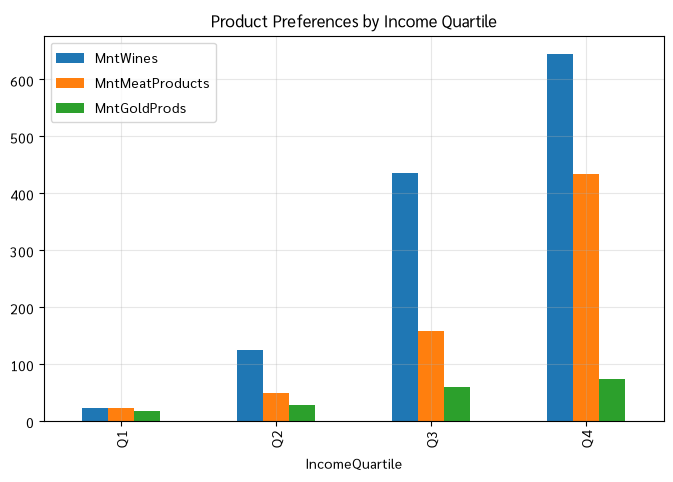

In [100]:
df['IncomeQuartile'] = pd.qcut(df['Income'], 4, labels=['Q1','Q2','Q3','Q4'])
print(df.groupby('IncomeQuartile', observed=False)[['MntWines','MntMeatProducts','MntGoldProds']].mean())

df.groupby('IncomeQuartile', observed=False)[['MntWines','MntMeatProducts','MntGoldProds']].mean().plot(kind='bar')

plt.title("Product Preferences by Income Quartile")
plt.grid(True)
plt.show()

---

<small>30. Create a correlation heatmap of product spending variables "MntWines", "MntMeatProducts", "MntSweetProducts", "MntGoldProds").<br> 
Which products are often purchased together, and what cross-selling opportunities exist?  


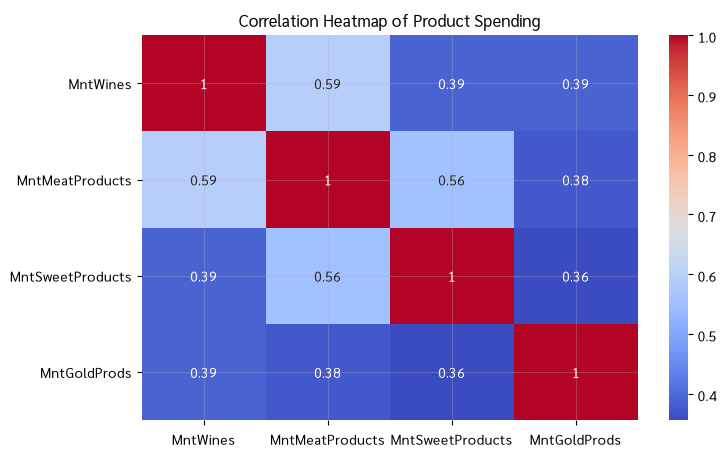

In [101]:
corr = df[['MntWines','MntMeatProducts','MntSweetProducts','MntGoldProds']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Product Spending")
plt.show()

---